<a href="https://colab.research.google.com/github/KrishivDawra/P7-End-Term/blob/main/P7_End_term.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
df = pd.read_csv("P7_Insurance_Premium.csv")
df.head()

,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions,Annual_Premium_INR
0,24,26.9,No,West,3,2,19404
1,29,26.9,No,North,0,0,15523
2,47,29.6,No,East,1,2,23858
3,42,33.3,No,South,2,3,28332
4,45,25.6,Yes,West,2,3,42681


In [40]:
df.shape

(800, 7)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      800 non-null    int64  
 1   BMI                      800 non-null    float64
 2   Smoker                   800 non-null    object 
 3   Region                   800 non-null    object 
 4   No_of_Dependents         800 non-null    int64  
 5   Pre_Existing_Conditions  800 non-null    int64  
 6   Annual_Premium_INR       800 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 43.9+ KB


In [42]:
df.isnull().sum()

,0
Age,0
BMI,0
Smoker,0
Region,0
No_of_Dependents,0
Pre_Existing_Conditions,0
Annual_Premium_INR,0


In [43]:
df.describe()

,Age,BMI,No_of_Dependents,Pre_Existing_Conditions,Annual_Premium_INR
count,800.000000,800.000000,800.000000,800.00000,800.000000
mean,40.355000,26.270625,2.070000,1.48750,24358.107500
std,13.546064,4.515566,1.371113,1.14082,7372.083963
min,18.000000,16.000000,0.000000,0.00000,8921.000000
25%,29.000000,23.000000,1.000000,0.00000,18938.000000
50%,40.000000,26.100000,2.000000,1.00000,23252.500000
75%,52.000000,29.100000,3.000000,3.00000,28074.000000
max,64.000000,42.000000,4.000000,3.00000,46294.000000


In [44]:
target_col = "Annual_Premium_INR"

In [45]:
df.head()

,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions,Annual_Premium_INR
0,24,26.9,No,West,3,2,19404
1,29,26.9,No,North,0,0,15523
2,47,29.6,No,East,1,2,23858
3,42,33.3,No,South,2,3,28332
4,45,25.6,Yes,West,2,3,42681


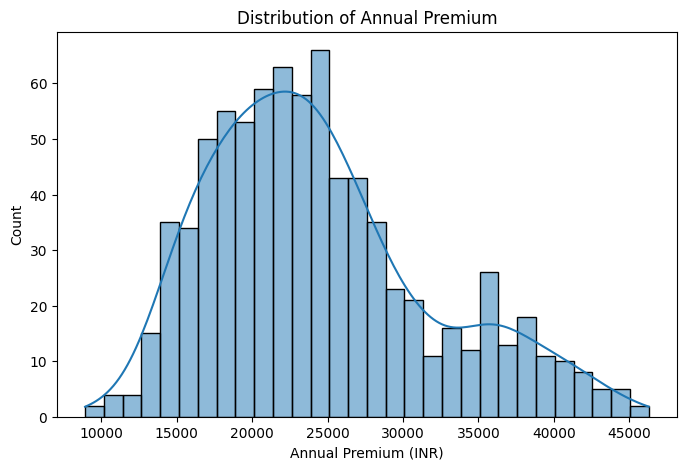

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df[target_col], kde=True, bins=30)
plt.title("Distribution of Annual Premium")
plt.xlabel("Annual Premium (INR)")
plt.ylabel("Count")
plt.show()

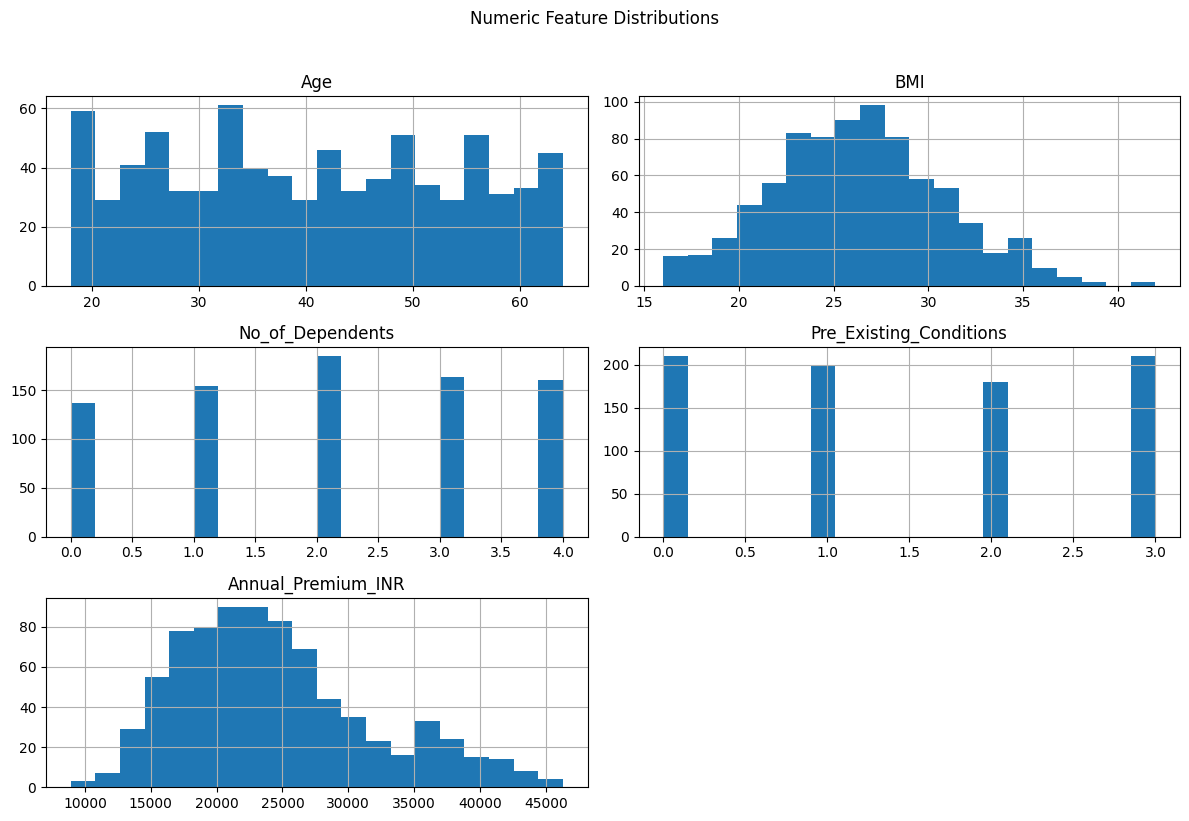

In [47]:
numeric_cols = ["Age", "BMI", "No_of_Dependents", "Pre_Existing_Conditions", target_col]

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

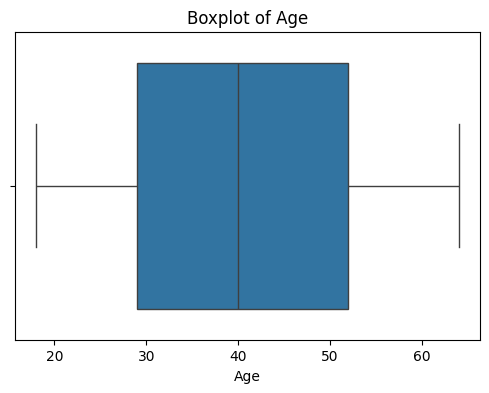

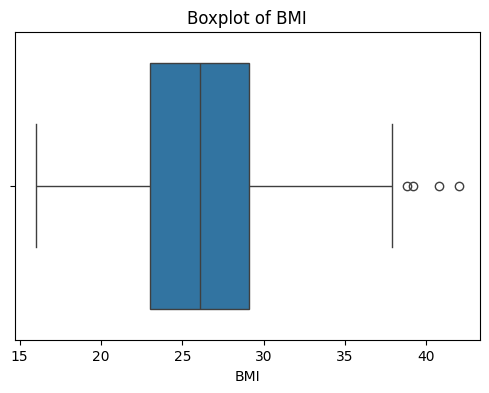

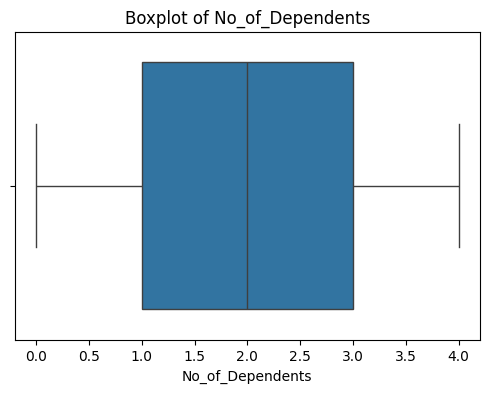

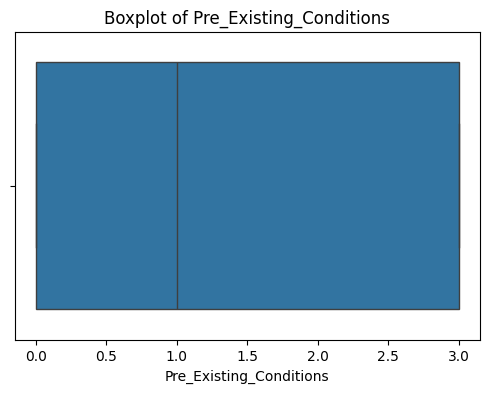

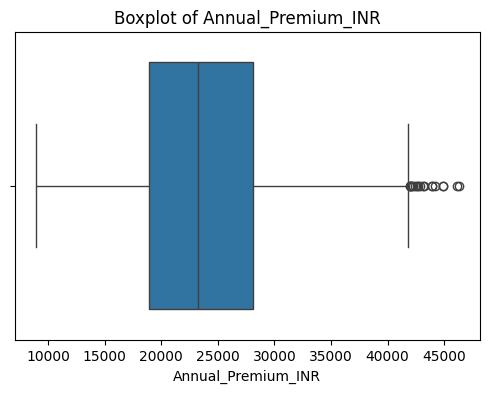

In [48]:
# Here we use BoxPlot - Outliers(spikes), Data spread (skewness or normal)
for col in ["Age", "BMI", "No_of_Dependents", "Pre_Existing_Conditions", target_col]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

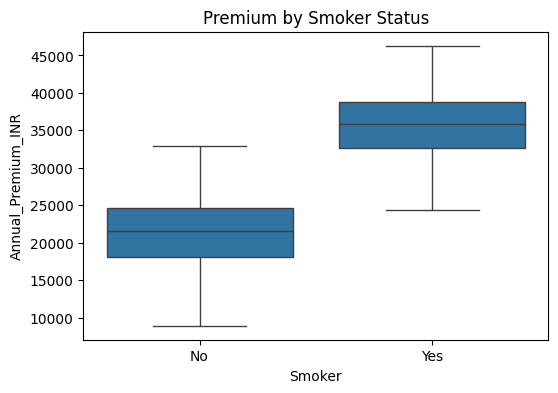

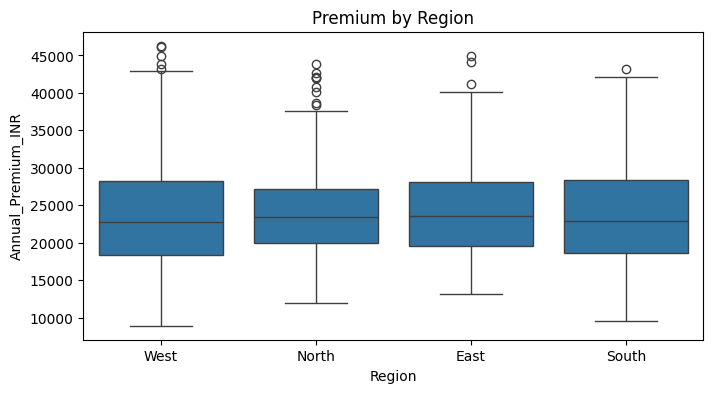

In [49]:
#smoking affects the premium or not
plt.figure(figsize=(6,4))
sns.boxplot(x="Smoker", y=target_col, data=df)
plt.title("Premium by Smoker Status")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="Region", y=target_col, data=df)
plt.title("Premium by Region")
plt.show()

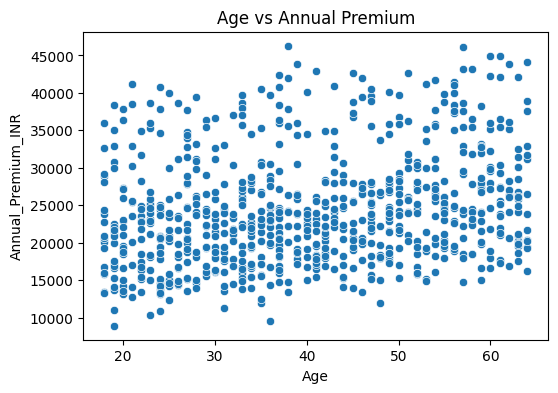

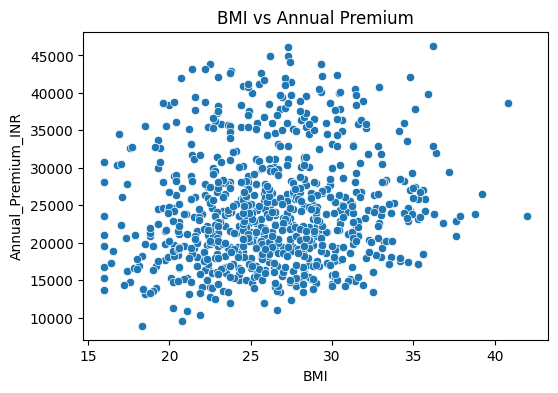

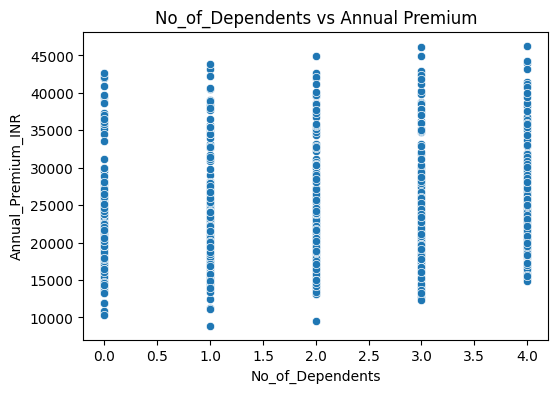

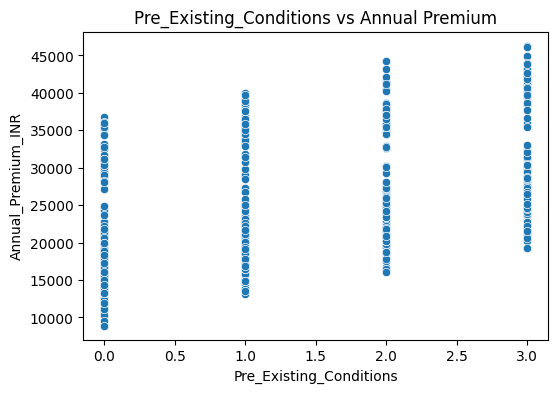

In [50]:
for col in ["Age", "BMI", "No_of_Dependents", "Pre_Existing_Conditions"]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target_col])
    plt.title(f"{col} vs Annual Premium")
    plt.show()

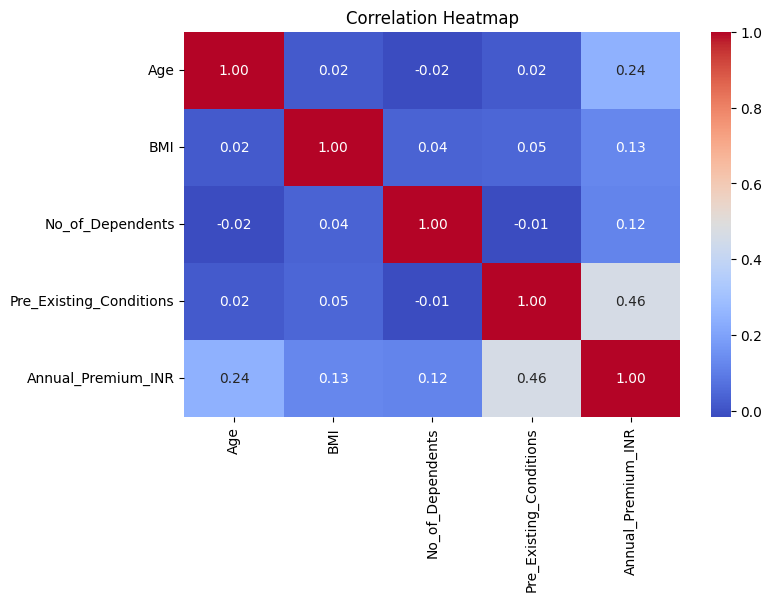

In [51]:
plt.figure(figsize=(8,5))
corr = df[["Age", "BMI", "No_of_Dependents", "Pre_Existing_Conditions", target_col]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [52]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (800, 6)
Target shape: (800,)


In [53]:
categorical_features = ["Smoker", "Region"]
numerical_features = ["Age", "BMI", "No_of_Dependents", "Pre_Existing_Conditions"]

In [54]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (640, 6)
X_test : (160, 6)


In [56]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None
    )
}

In [57]:
results = []

trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)

,Model,RMSE,MAE,R2 Score
0,Linear Regression,2076.075957,1668.044191,0.922422
1,Ridge Regression,2077.177472,1672.046469,0.922340
2,Random Forest,2404.397023,1966.739437,0.895945


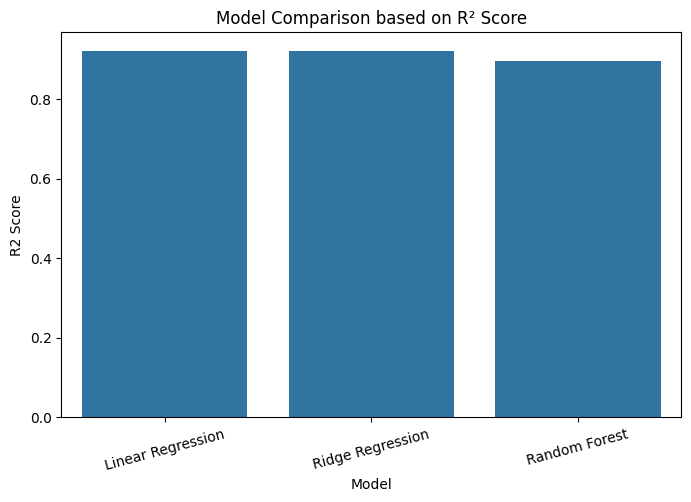

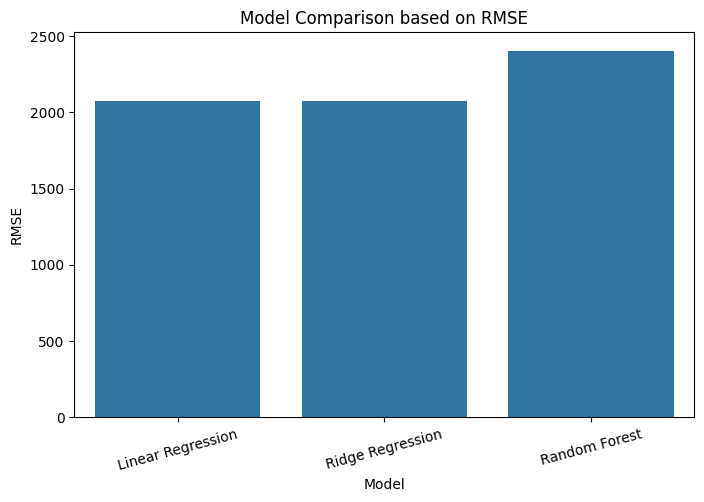

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.title("Model Comparison based on R² Score")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("Model Comparison based on RMSE")
plt.xticks(rotation=15)
plt.show()

In [59]:
# Feature importance -> For Linear Regression coefficients

best_linear_pipeline = trained_pipelines["Linear Regression"]

feature_names = best_linear_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_linear_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

display(coef_df)

,Feature,Coefficient,Abs_Coefficient
4,cat__Smoker_Yes,14714.828347,14714.828347
3,num__Pre_Existing_Conditions,3410.640171,3410.640171
0,num__Age,1593.603350,1593.603350
2,num__No_of_Dependents,1002.313792,1002.313792
1,num__BMI,833.081671,833.081671
5,cat__Region_North,770.373505,770.373505
6,cat__Region_South,-73.382773,73.382773
7,cat__Region_West,22.279247,22.279247


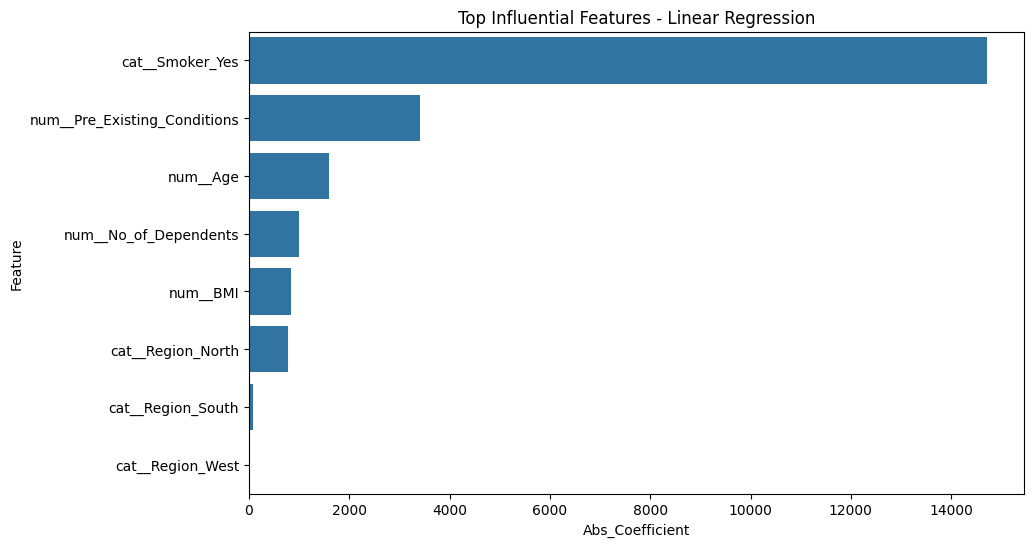

In [60]:
# Plot coefficient importance

plt.figure(figsize=(10,6))
sns.barplot(
    data=coef_df.head(10),
    x="Abs_Coefficient",
    y="Feature"
)
plt.title("Top Influential Features - Linear Regression")
plt.show()

In [61]:
# For Random Forest feature importance

rf_pipeline = trained_pipelines["Random Forest"]

rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

display(rf_importance_df)

,Feature,Importance
4,cat__Smoker_Yes,0.629367
3,num__Pre_Existing_Conditions,0.226647
0,num__Age,0.068929
1,num__BMI,0.040207
2,num__No_of_Dependents,0.024752
7,cat__Region_West,0.003527
5,cat__Region_North,0.003476
6,cat__Region_South,0.003095


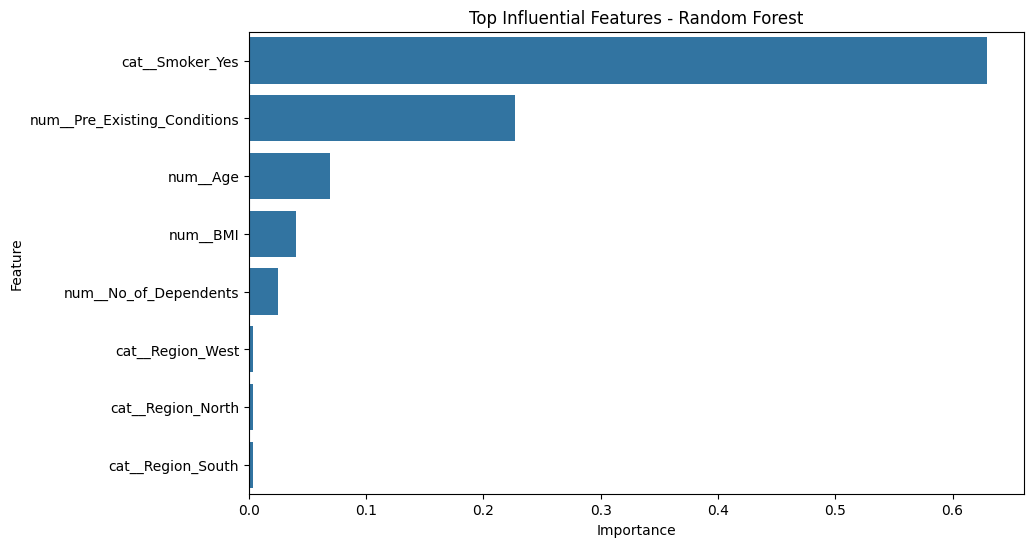

In [62]:
#Plotting Random Forest importance
plt.figure(figsize=(10,6))
sns.barplot(
    data=rf_importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top Influential Features - Random Forest")
plt.show()

In [63]:
#Predict premiums for 3 sample customer profiles

sample_customers = pd.DataFrame([
    {
        "Age": 25,
        "BMI": 22.5,
        "Smoker": "No",
        "Region": "North",
        "No_of_Dependents": 0,
        "Pre_Existing_Conditions": 0
    },
    {
        "Age": 40,
        "BMI": 29.0,
        "Smoker": "Yes",
        "Region": "West",
        "No_of_Dependents": 2,
        "Pre_Existing_Conditions": 2
    },
    {
        "Age": 55,
        "BMI": 31.5,
        "Smoker": "No",
        "Region": "South",
        "No_of_Dependents": 3,
        "Pre_Existing_Conditions": 3
    }
])

sample_customers

,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions
0,25,22.5,No,North,0,0
1,40,29.0,Yes,West,2,2
2,55,31.5,No,South,3,3


In [64]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

sample_predictions = best_model.predict(sample_customers)

prediction_df = sample_customers.copy()
prediction_df["Predicted_Annual_Premium_INR"] = sample_predictions.astype(int)

display(prediction_df)

,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions,Predicted_Annual_Premium_INR
0,25,22.5,No,North,0,0,13519
1,40,29.0,Yes,West,2,2,37897
2,55,31.5,No,South,3,3,29039


In [65]:
# Compare with simple industry benchmark ranges
def benchmark_premium(row):
    age = row["Age"]
    smoker = row["Smoker"]
    conditions = row["Pre_Existing_Conditions"]

    if smoker == "Yes" or conditions >= 2:
        return "High Risk: ~₹30,000 - ₹50,000+"
    elif age < 30 and conditions == 0:
        return "Low Risk: ~₹10,000 - ₹20,000"
    else:
        return "Moderate Risk: ~₹20,000 - ₹35,000"

prediction_df["Industry_Benchmark"] = prediction_df.apply(benchmark_premium, axis=1)
display(prediction_df)

,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions,Predicted_Annual_Premium_INR,Industry_Benchmark
0,25,22.5,No,North,0,0,13519,"Low Risk: ~₹10,000 - ₹20,000"
1,40,29.0,Yes,West,2,2,37897,"High Risk: ~₹30,000 - ₹50,000+"
2,55,31.5,No,South,3,3,29039,"High Risk: ~₹30,000 - ₹50,000+"


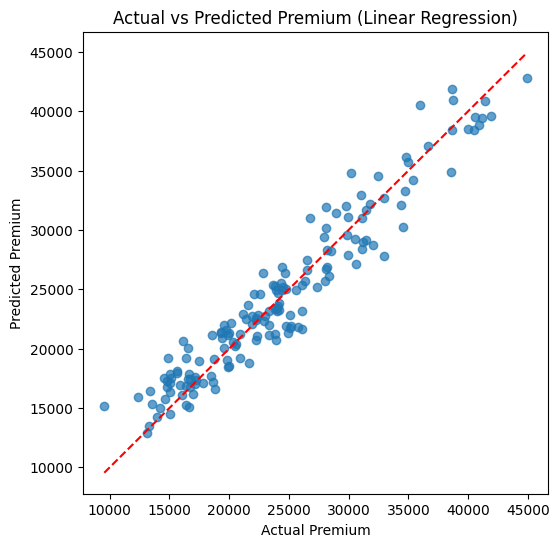

In [66]:
# Actual vs Predicted plot for best model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
plt.title(f"Actual vs Predicted Premium ({best_model_name})")

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

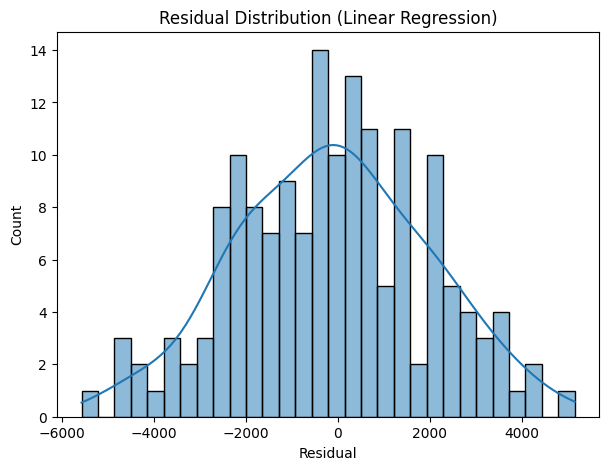

In [67]:
# Residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, bins=30)
plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Residual")
plt.show()

In [68]:
print("Best Model:", best_model_name)
print("\nModel Comparison:")
display(results_df)

print("\nTop Linear Regression Features:")
display(coef_df.head())

print("\nTop Random Forest Features:")
display(rf_importance_df.head())

print("\nSample Premium Predictions:")
display(prediction_df)

Best Model: Linear Regression

Model Comparison:


,Model,RMSE,MAE,R2 Score
0,Linear Regression,2076.075957,1668.044191,0.922422
1,Ridge Regression,2077.177472,1672.046469,0.922340
2,Random Forest,2404.397023,1966.739437,0.895945



Top Linear Regression Features:


,Feature,Coefficient,Abs_Coefficient
4,cat__Smoker_Yes,14714.828347,14714.828347
3,num__Pre_Existing_Conditions,3410.640171,3410.640171
0,num__Age,1593.603350,1593.603350
2,num__No_of_Dependents,1002.313792,1002.313792
1,num__BMI,833.081671,833.081671



Top Random Forest Features:


,Feature,Importance
4,cat__Smoker_Yes,0.629367
3,num__Pre_Existing_Conditions,0.226647
0,num__Age,0.068929
1,num__BMI,0.040207
2,num__No_of_Dependents,0.024752



Sample Premium Predictions:


,Age,BMI,Smoker,Region,No_of_Dependents,Pre_Existing_Conditions,Predicted_Annual_Premium_INR,Industry_Benchmark
0,25,22.5,No,North,0,0,13519,"Low Risk: ~₹10,000 - ₹20,000"
1,40,29.0,Yes,West,2,2,37897,"High Risk: ~₹30,000 - ₹50,000+"
2,55,31.5,No,South,3,3,29039,"High Risk: ~₹30,000 - ₹50,000+"
